This script creates Figure 7 of the paper

In [1]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#define models and timesteps used in this Figure

models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']
models_title=['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]
#offset=1920-syear

#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat

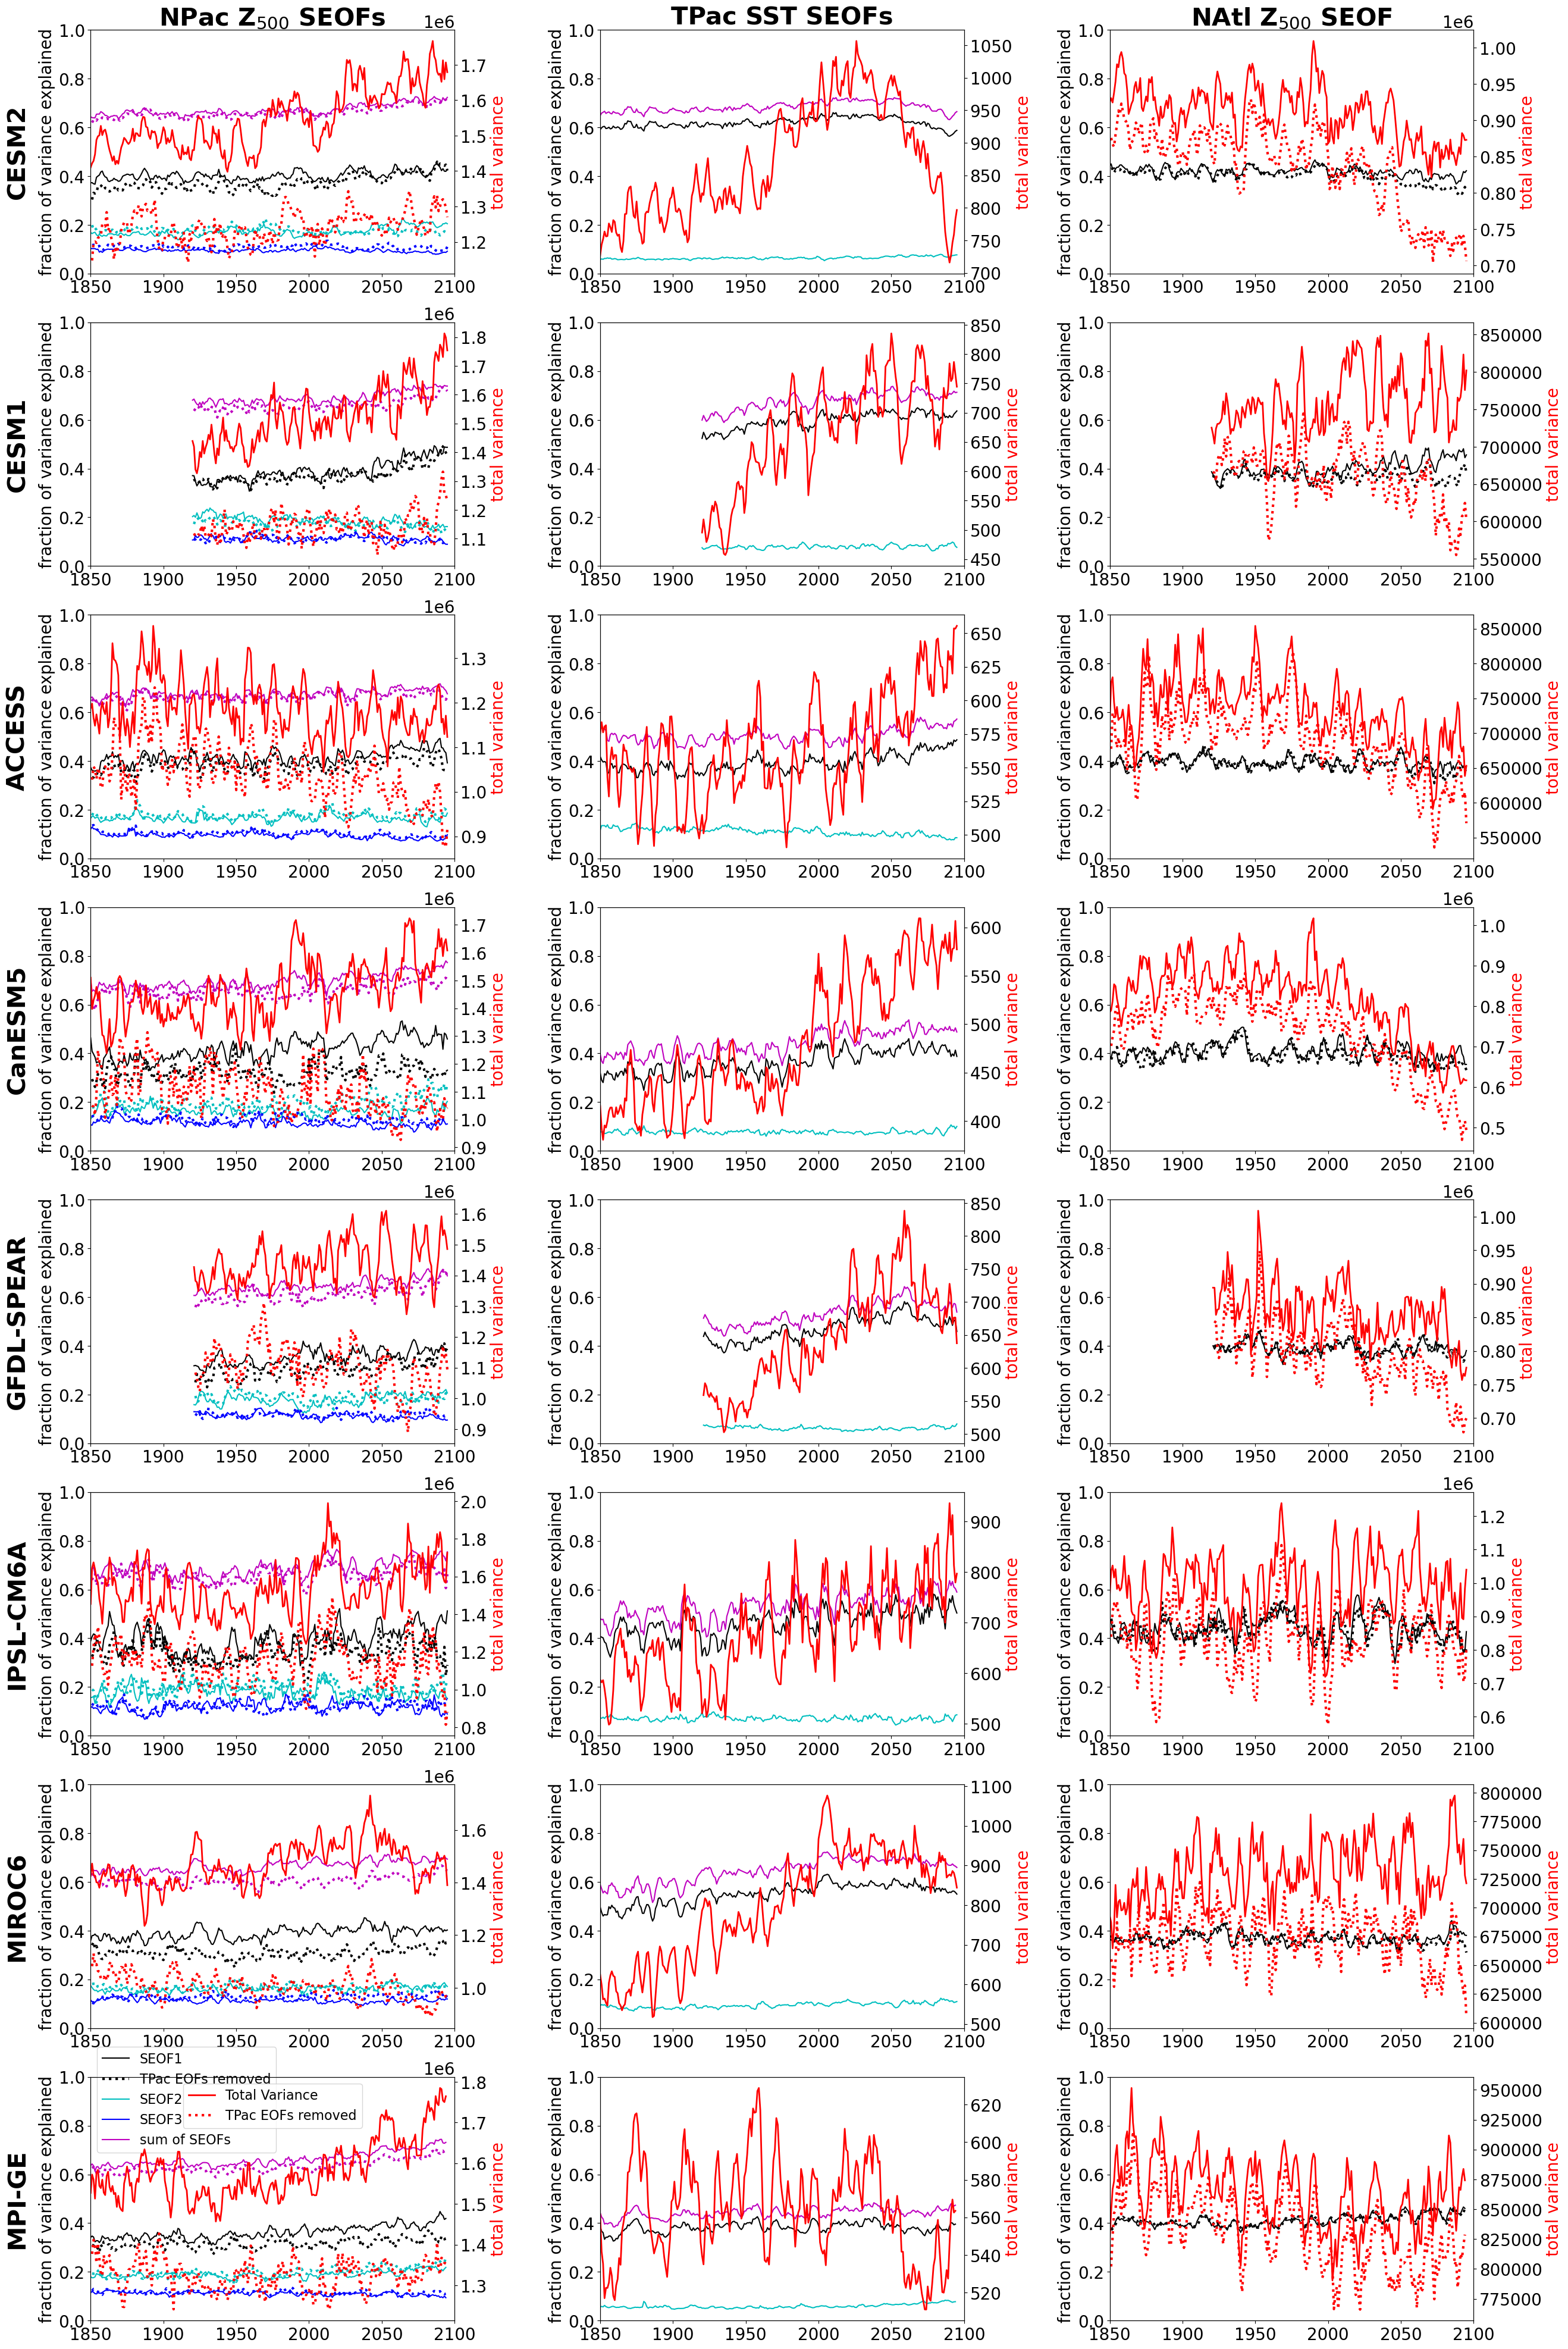

In [16]:
#load data and plot
outputdir2='/glade/work/nmaher/SEOF_output/'
outputdir2b='/glade/work/nmaher/SEOF_output/Fig_data/'

from matplotlib.gridspec import GridSpec

#fig,axs = PP.subplots(10,4,figsize=(35,20), subplot_kw={'projection': ccrs.Robinson(central_longitude=270)})
#fig = plt.figure(figsize=(45,100))

fig = plt.figure(figsize=(30,50))
gs=GridSpec(8,3, wspace=0.4)


ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]
    

    eof_T='_PNA'
    with np.load(outputdir2+model+eof_T+'_FVAR.npz') as npz:
        pac_fvar = np.ma.MaskedArray(**npz)
    
    with np.load(outputdir2+model+eof_T+'_TVAR.npz') as npz:
        pac_tvar = np.ma.MaskedArray(**npz)

    eof_T='_NAT'
    with np.load(outputdir2+model+eof_T+'_FVAR.npz') as npz:
        nat_fvar = np.ma.MaskedArray(**npz)

    with np.load(outputdir2+model+eof_T+'_TVAR.npz') as npz:
        nat_tvar = np.ma.MaskedArray(**npz)
        
        
    eof_T='_TPAC_SST'
    with np.load(outputdir2+model+eof_T+'_FVAR.npz') as npz:
        tpac_fvar = np.ma.MaskedArray(**npz)
    
    with np.load(outputdir2+model+eof_T+'_TVAR.npz') as npz:
        tpac_tvar = np.ma.MaskedArray(**npz)


    eof_T='_F6data_zg'
    with np.load(outputdir2b+model+eof_T+'_NPAC_FVAR.npz') as npz:
        pac_fvar_rem = np.ma.MaskedArray(**npz)
    
    with np.load(outputdir2b+model+eof_T+'_NPAC_TVAR.npz') as npz:
        pac_tvar_rem = np.ma.MaskedArray(**npz)

    eof_T='_F6data_zg'
    with np.load(outputdir2b+model+eof_T+'_NAO_FVAR.npz') as npz:
        nat_fvar_rem = np.ma.MaskedArray(**npz)
    
    with np.load(outputdir2b+model+eof_T+'_NAO_TVAR.npz') as npz:
        nat_tvar_rem = np.ma.MaskedArray(**npz)
    
        
    ax1 =plt.subplot(gs[ii,0])
    time=np.zeros(len(pac_fvar))
    for i in range(len(pac_fvar)):
        time[i]=syear[ii]+i
    d,=ax1.plot(time,pac_fvar[:,0],'k')
    e,=ax1.plot(time,pac_fvar[:,1],'c')
    f,=ax1.plot(time,pac_fvar[:,2],'b')
    c,=ax1.plot(time,pac_fvar[:,0]+pac_fvar[:,1]+pac_fvar[:,2],'m')

    g,=ax1.plot(time[1:],pac_fvar_rem[:,0],'k:',linewidth=3)
    ax1.plot(time[1:],pac_fvar_rem[:,1],'c:',linewidth=3)
    ax1.plot(time[1:],pac_fvar_rem[:,2],'b:',linewidth=3)
    ax1.plot(time[1:],pac_fvar_rem[:,0]+pac_fvar_rem[:,1]+pac_fvar_rem[:,2],'m:',linewidth=3)
    
    ax1.set_ylim(0,1)
    ax1.set_xlim(1850,2100)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)

    ax2 = ax1.twinx()  
    a,=ax2.plot(time,pac_tvar,'r',linewidth=2)
    b,=ax2.plot(time[1:],pac_tvar_rem,'r:',linewidth=3)
    ax1.set_ylabel('fraction of variance explained',fontsize=35)
    ax2.set_ylabel('total variance',fontsize=35,color='r')
    ax1.yaxis.label.set_size(20)
    ax2.yaxis.label.set_size(20)
    ax1.xaxis.label.set_size(20)
    ax2.xaxis.label.set_size(20)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)
    ax2.yaxis.get_offset_text().set_fontsize(20)
    
    if ii==7:
     #   ax2.legend([a,b,c,d,e],['dd','dd','gg','gg','hh'])
    #ax1.legend(bbox_to_anchor=(1, 1),
     #     bbox_transform=fig.transFigure)    
        ax2.legend([a,b],['Total Variance','TPac EOFs removed'],loc='upper center',fontsize=16)
        ax1.legend([d,g,e,f,c],['SEOF1','TPac EOFs removed','SEOF2','SEOF3','sum of SEOFs'],loc='upper left',bbox_to_anchor=(0, 1.15),fontsize=16)

    #ax2.set_ylim(4, 20);
    if ii==0:
        ax1.set_title('NPac Z$_{500}$ SEOFs', fontsize=30, weight='bold')

    ax1.text(1800,0.5,models_title[ii], rotation=90, fontsize=30, ha='center', va='center', weight='bold')   
    
    ax1 =plt.subplot(gs[ii,1])
    ax1.plot(time,tpac_fvar[:,0],'k')
    ax1.plot(time,tpac_fvar[:,1],'c')
    ax1.plot(time,tpac_fvar[:,0]+tpac_fvar[:,1],'m')

    ax1.set_ylim(0,1)
    ax1.set_xlim(1850,2100)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)

    ax2 = ax1.twinx()  
    ax2.plot(time,tpac_tvar,'r',linewidth=2)
    #ax2.set_ylim(4, 20);
    ax1.set_ylabel('fraction of variance explained',fontsize=35)
    ax2.set_ylabel('total variance',fontsize=35,color='r')
    ax1.yaxis.label.set_size(20)
    ax2.yaxis.label.set_size(20)
    ax1.xaxis.label.set_size(20)
    ax2.xaxis.label.set_size(20)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)
    ax2.yaxis.get_offset_text().set_fontsize(20)
    
    if ii==0:
        ax1.set_title('TPac SST SEOFs', fontsize=30, weight='bold')

    
    ax1 =plt.subplot(gs[ii,2])
    ax1.plot(time,nat_fvar[:,0],'k')
    ax1.plot(time[1:],nat_fvar_rem[:,0],'k:',linewidth=3)
    ax1.set_ylim(0,1)

    ax1.set_xlim(1850,2100)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)
    ax2 = ax1.twinx()  
    ax2.plot(time,nat_tvar,'r',linewidth=2)
    ax2.plot(time[1:],nat_tvar_rem,'r:',linewidth=3)
    
    #ax2.set_ylim(4, 20);
    ax1.set_ylabel('fraction of variance explained',fontsize=20)
    ax2.set_ylabel('total variance',fontsize=20,color='r')
    ax1.yaxis.label.set_size(20)
    ax2.yaxis.label.set_size(20)
    ax1.xaxis.label.set_size(20)
    ax2.xaxis.label.set_size(20)
    plt.yticks(fontsize=20)
    plt.xticks(fontsize=20)
    ax2.yaxis.get_offset_text().set_fontsize(20)

    if ii==0:
        ax1.set_title('NAtl Z$_{500}$ SEOF', fontsize=30, weight='bold')
        
#plt.text(-0.04,0.5,models_title[0], rotation=90, fontsize=12, ha='center', va='center', transform=gs[0,0])
         
         #.transAxes)
#plt.text(-0.04,0.5,models_title[1], rotation=90, fontsize=12, ha='center', va='center', transform=axs[1,0].transAxes)
#plt.text(-0.04,0.5,models_title[2], rotation=90, fontsize=12, ha='center', va='center', transform=axs[2,0].transAxes)
#plt.text(-0.04,0.5,models_title[3], rotation=90, fontsize=12, ha='center', va='center', transform=axs[3,0].transAxes)
#plt.text(-0.04,0.5,models_title[4], rotation=90, fontsize=12, ha='center', va='center', transform=axs[4,0].transAxes)
#plt.text(-0.04,0.5,models_title[5], rotation=90, fontsize=12, ha='center', va='center', transform=axs[5,0].transAxes)
#plt.text(-0.04,0.5,models_title[6], rotation=90, fontsize=12, ha='center', va='center', transform=axs[6,0].transAxes)
#plt.text(-0.04,0.5,models_title[7], rotation=90, fontsize=12, ha='center', va='center', transform=axs[7,0].transAxes)


#plt[0,1].set_title('TPac SST SEOFs', fontsize=24, weight='bold')
#plt[0,2].set_title('NAtl Z$_{500}$ SEOF', fontsize=24, weight='bold')

plt.rcParams["legend.fontsize"] = 16
outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'

plt.savefig(outputdir2+'Figure7.png')
plt.show()